In [1]:
# Import relevant libaries
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

In [2]:
# Read dataset 

healthcare_df = pd.read_csv('healthcare_stroke_dataset.csv')
healthcare_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
healthcare_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [4]:
# Checking for duplicates
healthcare_df.duplicated().sum()

np.int64(0)

In [5]:
healthcare_df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [6]:
healthcare_df['bmi'].isnull().sum()

np.int64(201)

In [7]:
# Check the rate of missing bmi by the stroke

healthcare_df.groupby(healthcare_df['bmi'].isnull().astype(int))['stroke'].mean() * 100

bmi
0     4.257486
1    19.900498
Name: stroke, dtype: float64

Only 4% of non stroke patients have missing values
while 19.9% of stroke patients have missing bmi values
We may then conclude that stroke patients are less likely to have BMI recorded duebto physical challenges.

In [8]:
# fill missing bmi values by its median within each stroke group
healthcare_df['bmi'] = healthcare_df.groupby('stroke')['bmi'].transform(lambda x: x.fillna(x.median()))

In [9]:
healthcare_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


### Feature Engineering

In [10]:
# Create a new feature that categorizes age
# Define function to categorize age
def categorize_age(age):
    if age < 18:
        return 'Child'
    elif 18 <= age < 65:
        return 'Adult'
    else:
        return 'Senior'

# Apply function to the 'age' column to create the new 'age_category' column
healthcare_df['age_category'] = healthcare_df['age'].apply(categorize_age)
healthcare_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_category
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Senior
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,29.7,never smoked,1,Adult
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Senior
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Adult
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Senior


In [11]:
# Create a new feature 'Glucose risk tier'
# Normal(<100)
# Pre-diabetic(100-125)
# Diabetic(>126)

def categorize_glucose(avg_glucose_level):
    if avg_glucose_level <= 100:
        return 'Normal'
    elif 100 < avg_glucose_level < 126:
        return 'Pre-diabetic'
    else:
        return 'Diabetic'

healthcare_df['glucose_tier'] = healthcare_df['avg_glucose_level'].apply(categorize_glucose)
healthcare_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_category,glucose_tier
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Senior,Diabetic
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,29.7,never smoked,1,Adult,Diabetic
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Senior,Pre-diabetic
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Adult,Diabetic
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Senior,Diabetic


In [12]:
# Create a new feature 'bmi tier'
# Underweight (0 - 18.5)
# Normal (18.5- 25)
# Overweight(25 - 230)
# Obese (>=30)

def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25:
        return 'Normal'
    elif 25 <= bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

healthcare_df['bmi_tier'] = healthcare_df['bmi'].apply(categorize_bmi)
healthcare_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_category,glucose_tier,bmi_tier
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Senior,Diabetic,Obese
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,29.7,never smoked,1,Adult,Diabetic,Overweight
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Senior,Pre-diabetic,Obese
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Adult,Diabetic,Obese
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Senior,Diabetic,Normal


### Univariate Analysis

In [13]:
# Stroke prevalence
stroke_prev = healthcare_df["stroke"].value_counts()
print(f'The prevalence of stroke is {stroke_prev}')

The prevalence of stroke is stroke
0    4861
1     249
Name: count, dtype: int64


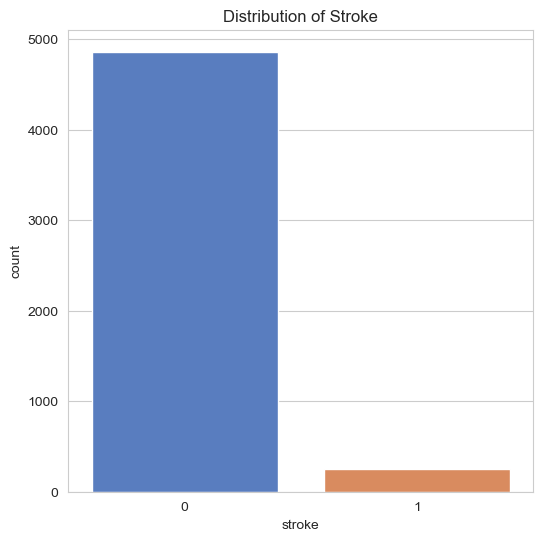

In [14]:
# Set the style of all graphs to seaborn
sns.set_style("whitegrid")

# Plot the target variable 'stroke'
plt.figure(figsize=(6, 6))
sns.countplot(x=healthcare_df['stroke'], palette='muted')
plt.title('Distribution of Stroke')
plt.savefig('Stroke Count')
plt.show()


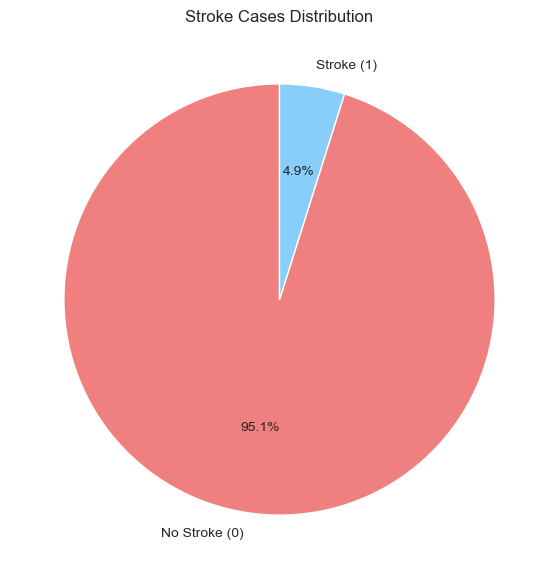

In [15]:

plt.figure(figsize=(7, 7))
plt.pie(stroke_prev, 
        labels=['No Stroke (0)', 'Stroke (1)'], 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=['lightcoral', 'lightskyblue'])
plt.title('Stroke Cases Distribution')
plt.ylabel('') # Hide the default 'y' label
plt.savefig('Stroke prev pie')
plt.show()

The target variable 'stroke' is highly imbalanced with a lot more instances of class 0 (no stroke) than class 1 (stroke). 

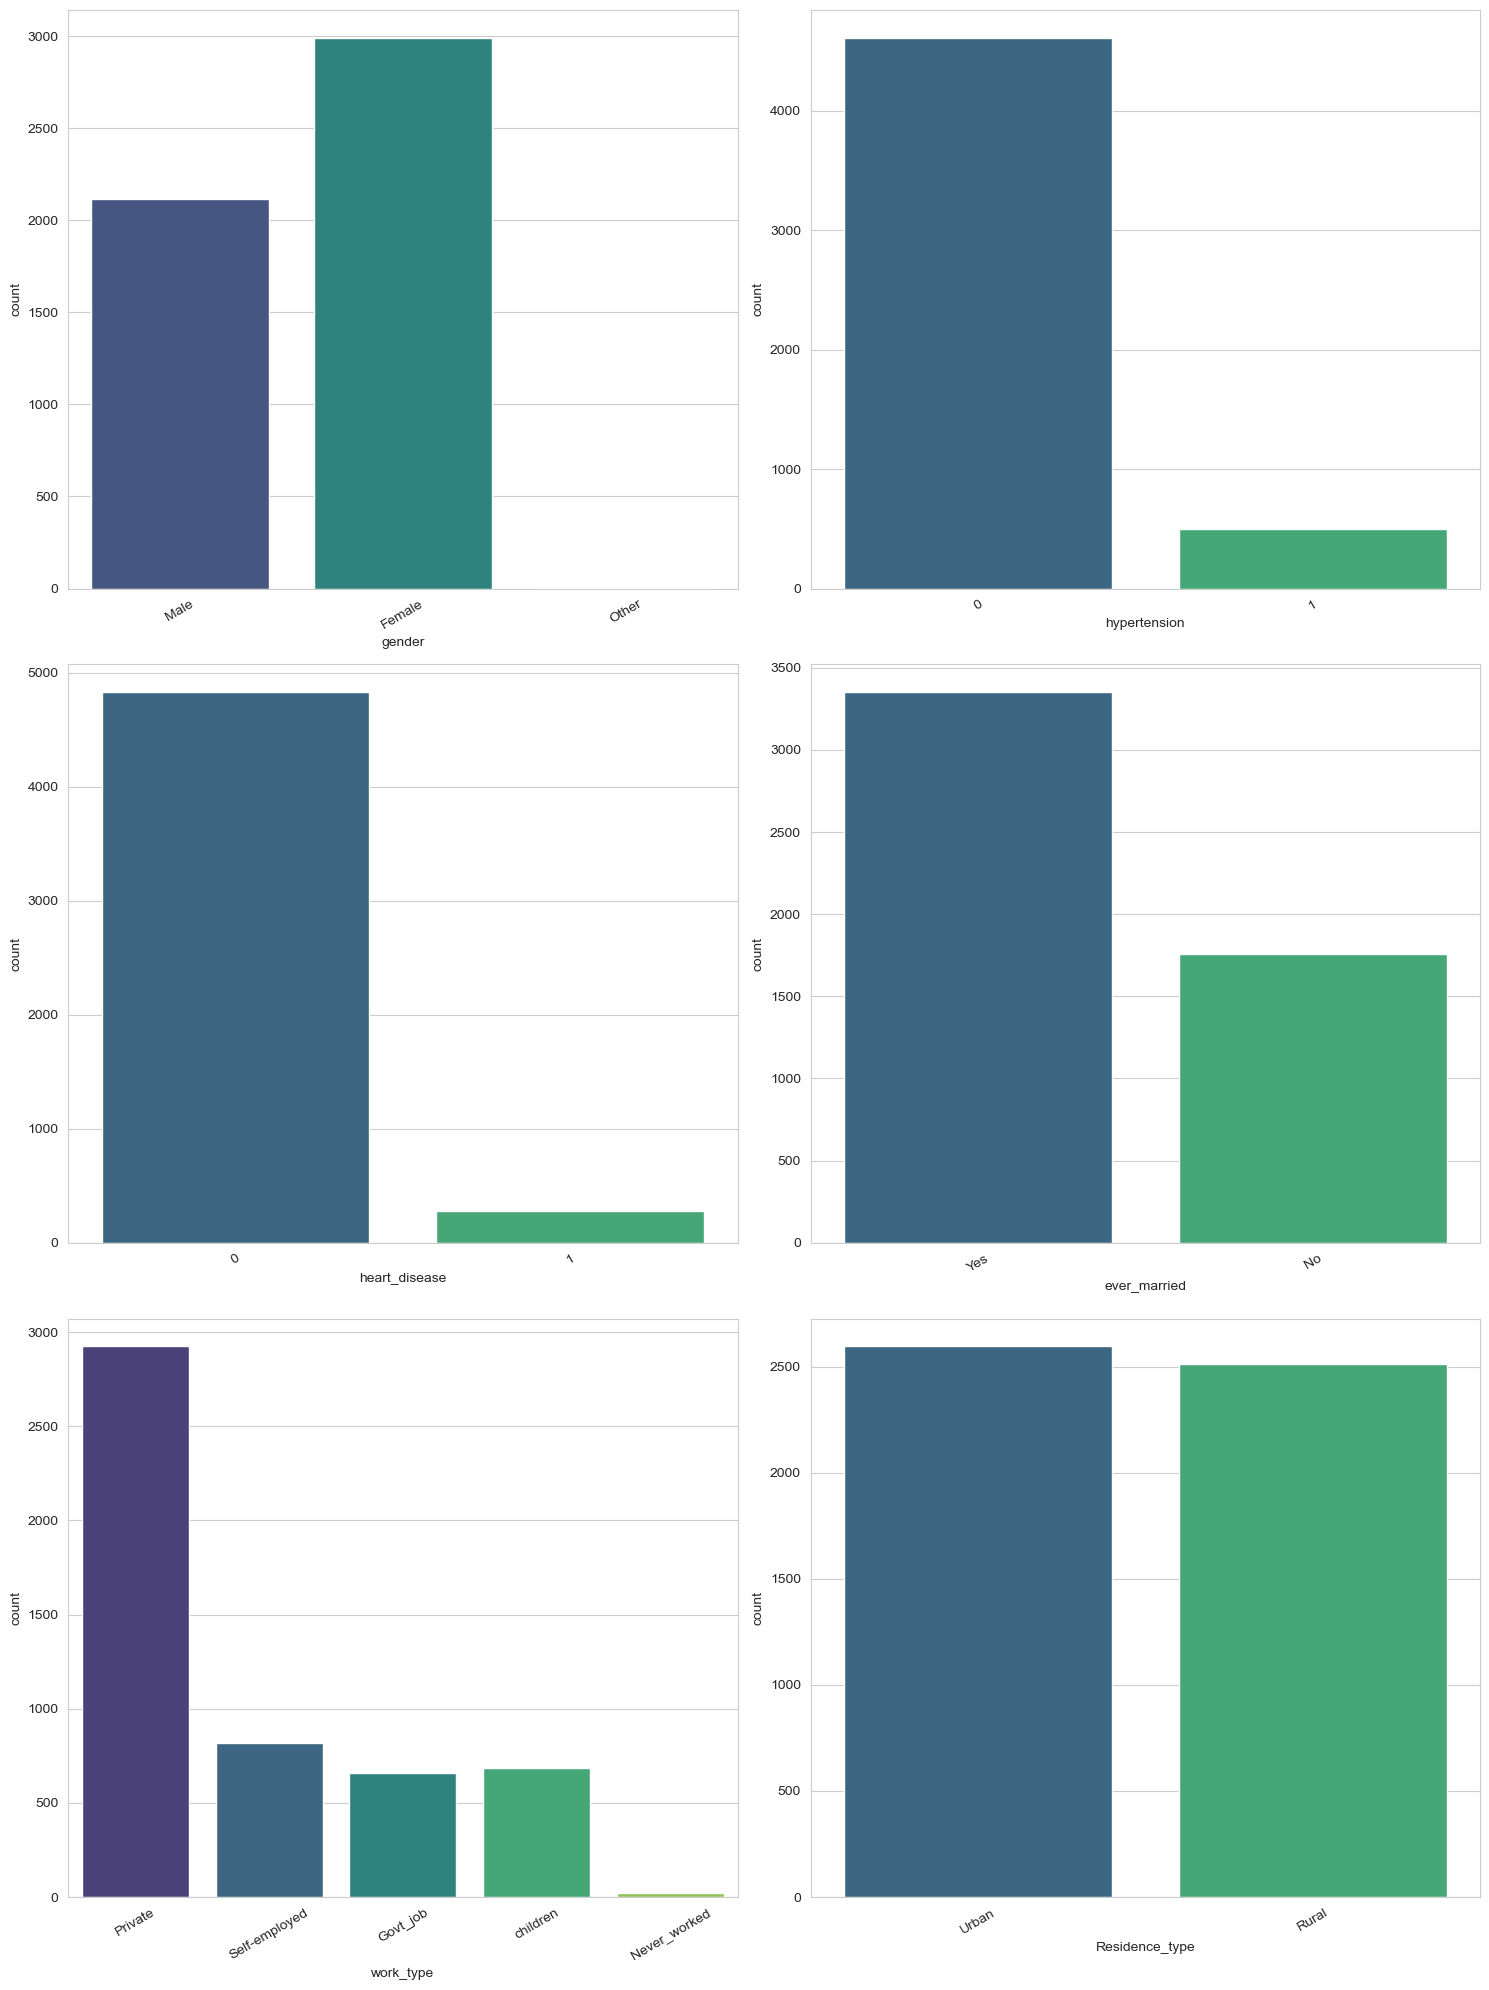

In [16]:
# List of categorical variables
cat_var = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type']

# Plotting the bar plots
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(15, 20))

for var, subplot in zip(cat_var, ax.flatten()):
    sns.countplot(x=var, data=healthcare_df, ax=subplot, palette='viridis')
    for label in subplot.get_xticklabels():
        label.set_rotation(30)

plt.tight_layout()
plt.savefig('Cat Variable count')
plt.show()


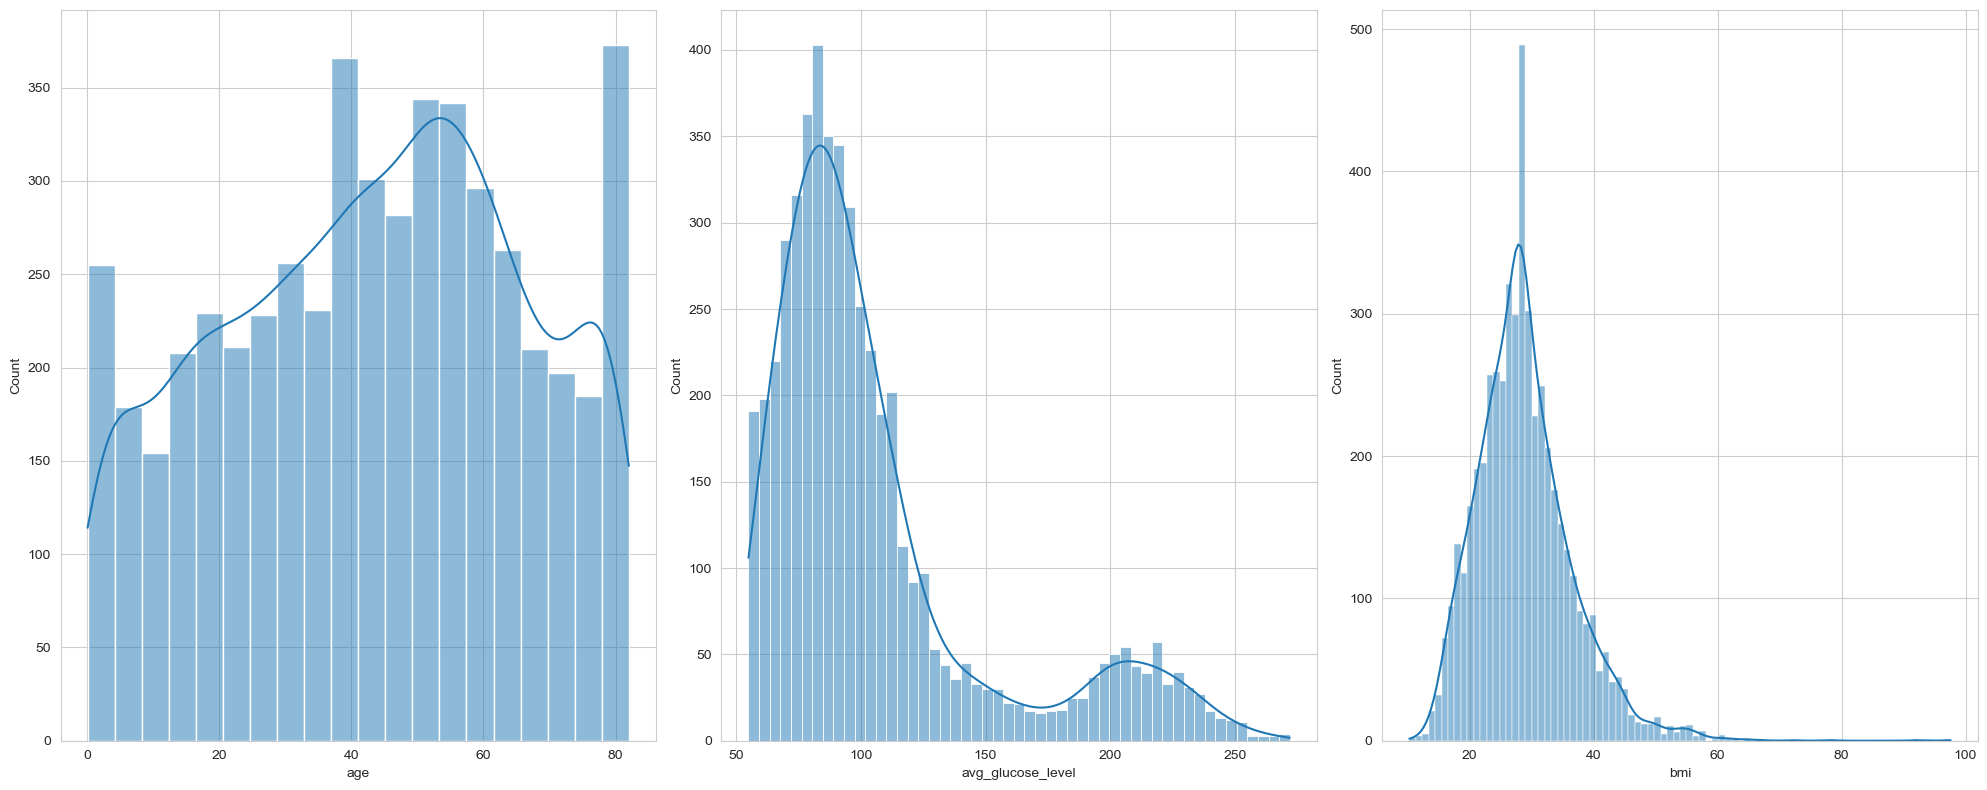

In [17]:
# Continous Vairable 

cont_var = ['age', 'avg_glucose_level', 'bmi']

# Plot the histograms for continuous variables
fig, ax = plt.subplots(1, 3, figsize=(20, 8))

for var, subplot in zip(cont_var, ax.flatten()):
    sns.histplot(healthcare_df[var], kde=True, ax=subplot)

plt.tight_layout()
plt.savefig('Cont Variable dist')
plt.show()

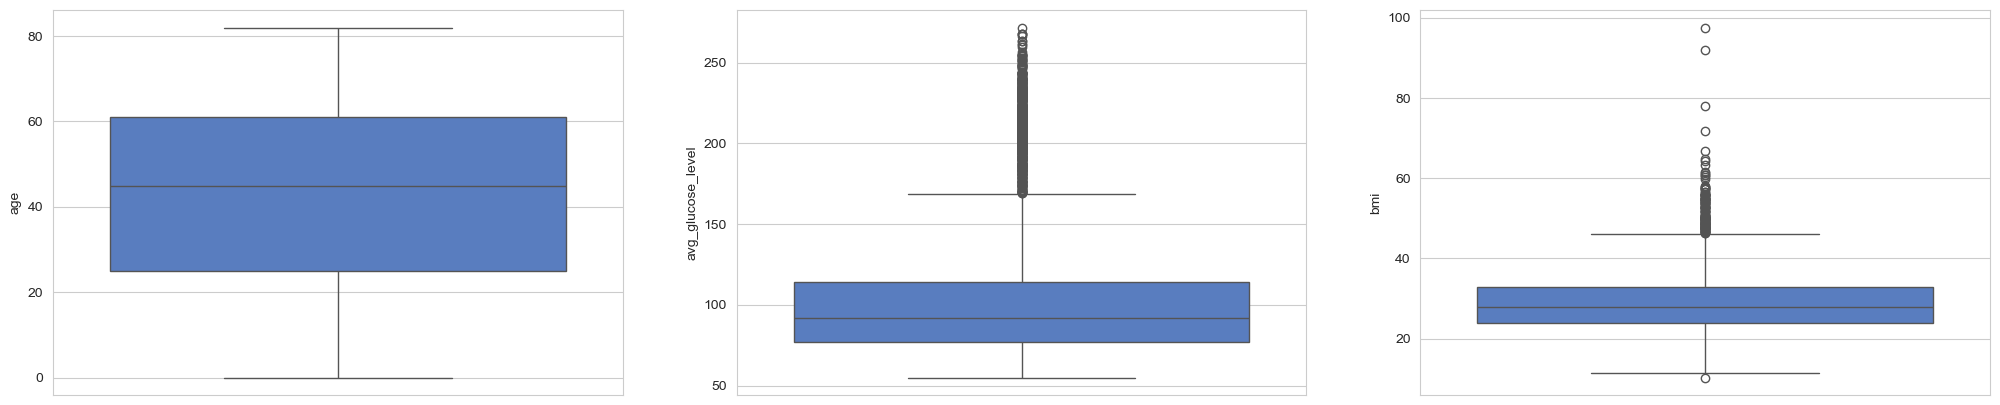

In [18]:
cont_var = ['age', 'avg_glucose_level', 'bmi']
# Plot the boxplots for continuous variables
fig, ax = plt.subplots(1, 3, figsize=(25, 5))

for var, subplot in zip(cont_var, ax.flatten()):
    sns.boxplot(healthcare_df[var], ax=subplot, palette='muted')

plt.savefig('Cont var boxplot')

### Bivariate Analysis

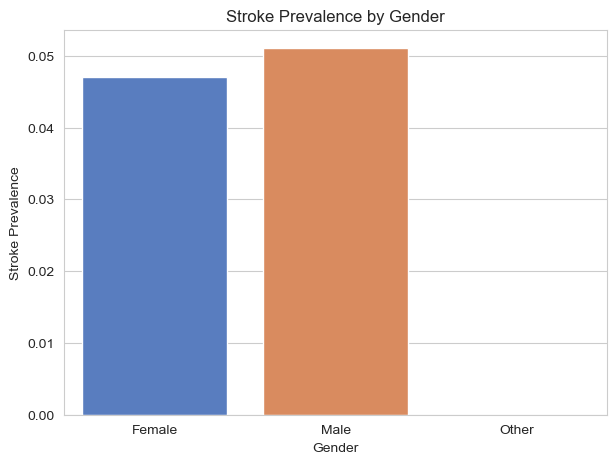

In [19]:
# Gender vs stroke 
gender_stroke_prev = healthcare_df.groupby('gender')['stroke'].mean().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(x='gender', 
            y='stroke', 
            data=gender_stroke_prev, 
            palette='muted', 
            hue='gender', 
            legend=False)
plt.title('Stroke Prevalence by Gender')
plt.xlabel('Gender')
plt.ylabel('Stroke Prevalence')
plt.savefig('Stroke by Gender')
plt.show()

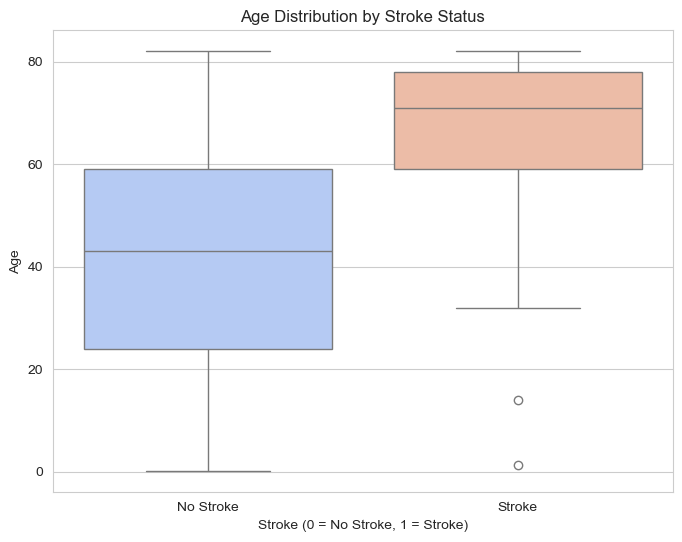

In [20]:
# Age vs Stroke 

plt.figure(figsize=(8, 6))
sns.boxplot(x='stroke', y='age', data=healthcare_df, palette='coolwarm')
plt.title('Age Distribution by Stroke Status')
plt.xlabel('Stroke (0 = No Stroke, 1 = Stroke)')
plt.ylabel('Age')
plt.xticks([0, 1], ['No Stroke', 'Stroke'])
plt.savefig('Age by Stroke')
plt.show()

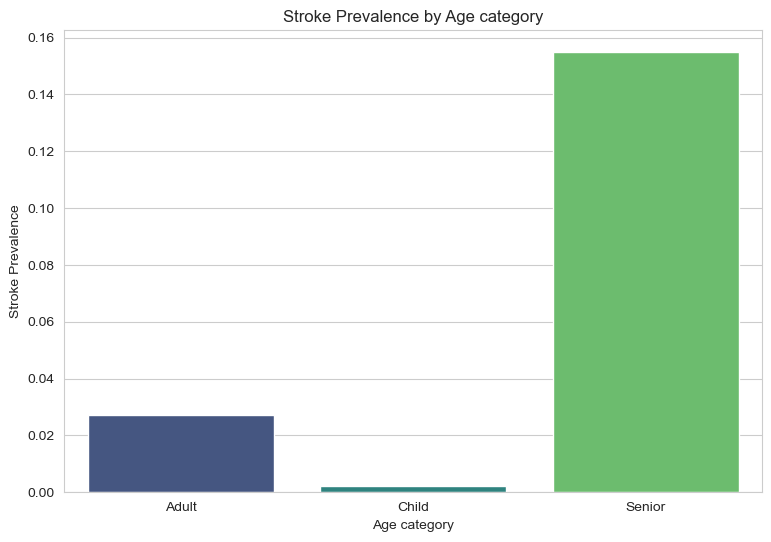

In [21]:
# Age category by stroke 

age_stroke_prev = healthcare_df.groupby('age_category')['stroke'].mean().reset_index()

plt.figure(figsize=(9, 6))
sns.barplot(x='age_category', 
            y='stroke', 
            data=age_stroke_prev, 
            palette='viridis', 
            hue='age_category', 
            legend=False)
plt.title('Stroke Prevalence by Age category')
plt.xlabel('Age category')
plt.ylabel('Stroke Prevalence')
plt.savefig('stroke by age cat')
plt.show()

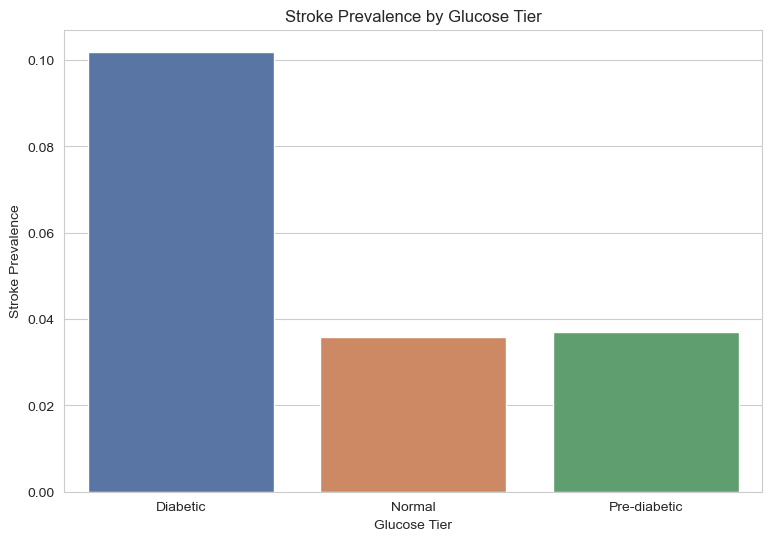

In [22]:
# Glucose tier by Stroke 

glucose_stroke_prev = healthcare_df.groupby('glucose_tier')['stroke'].mean().reset_index()

plt.figure(figsize=(9, 6))
sns.barplot(x='glucose_tier', 
            y='stroke', 
            data=glucose_stroke_prev, 
            palette='deep', 
            hue='glucose_tier', 
            legend=False)
plt.title('Stroke Prevalence by Glucose Tier')
plt.xlabel('Glucose Tier')
plt.ylabel('Stroke Prevalence')
plt.savefig('Stroke by Glucose Tier')
plt.show()

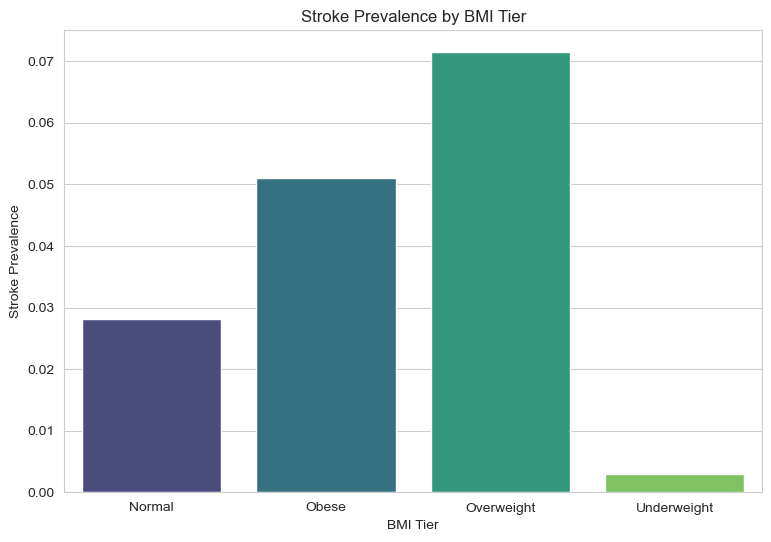

In [23]:
# BMI tier vs Stroke 

bmi_stroke_prev = healthcare_df.groupby('bmi_tier')['stroke'].mean().reset_index()

plt.figure(figsize=(9, 6))
sns.barplot(x='bmi_tier', 
            y='stroke', 
            data=bmi_stroke_prev, 
            palette='viridis', 
            hue='bmi_tier', 
            legend=False)
plt.title('Stroke Prevalence by BMI Tier')
plt.xlabel('BMI Tier')
plt.ylabel('Stroke Prevalence')
plt.savefig('Stroke by BMI Tier')
plt.show()

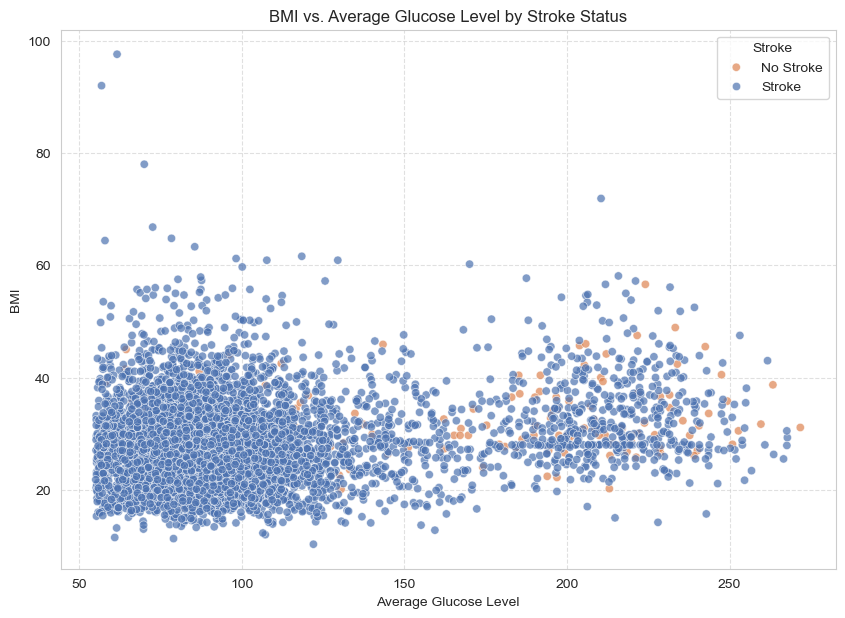

In [24]:
# bmi vs glucose 

plt.figure(figsize=(10, 7))
sns.scatterplot(x='avg_glucose_level', y='bmi', hue='stroke', data=healthcare_df, palette='deep', alpha=0.7)
plt.title('BMI vs. Average Glucose Level by Stroke Status')
plt.xlabel('Average Glucose Level')
plt.ylabel('BMI')
plt.legend(title='Stroke', labels=['No Stroke', 'Stroke'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('bmi-glucose scatter')
plt.show()

### Multivariate Analysis

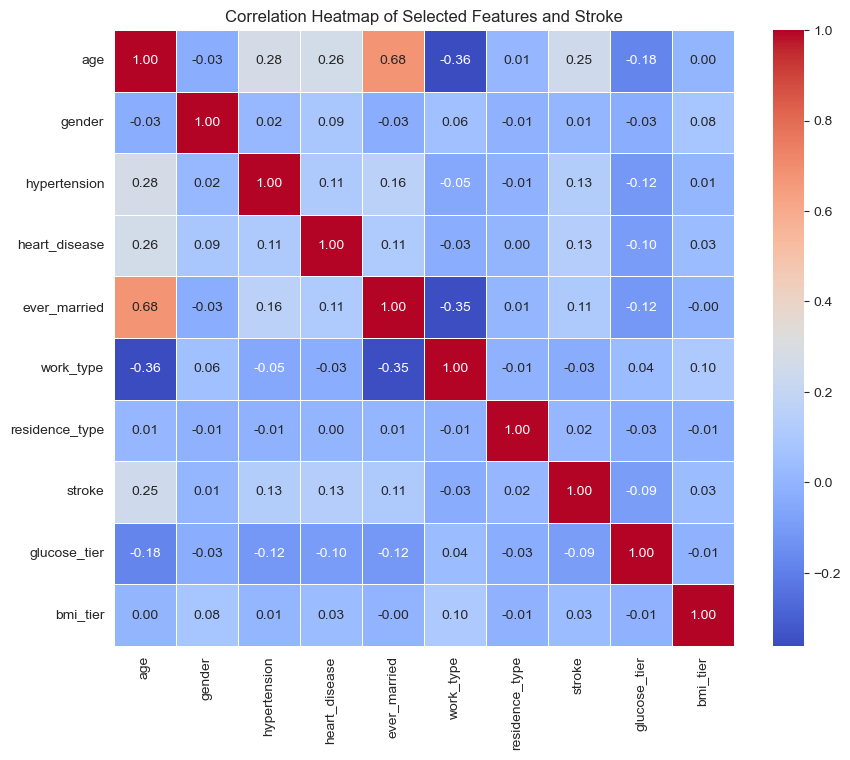

In [25]:
# Create a correlation heatmap 
# Convert the categorical features into numerical 
from sklearn.preprocessing import LabelEncoder

# Make a copy of the dataframe to avoid modifying the original 'stroke_df' directly for this operation
df_encoded = healthcare_df.copy()

# Initialize LabelEncoder
le = LabelEncoder()

# Encode categorical features
df_encoded['gender'] = le.fit_transform(df_encoded['gender'])
df_encoded['ever_married'] = le.fit_transform(df_encoded['ever_married'])
df_encoded['work_type'] = le.fit_transform(df_encoded['work_type'])
df_encoded['residence_type'] = le.fit_transform(df_encoded['Residence_type'])
df_encoded['smoking_status'] = le.fit_transform(df_encoded['smoking_status'])
df_encoded['glucose_tier'] = le.fit_transform(df_encoded['glucose_tier']) 
df_encoded['bmi_tier'] = le.fit_transform(df_encoded['bmi_tier'])

# Select the columns for the heatmap, including the newly encoded ones
cols_for_corr = [
    'age',
    'gender',
    'hypertension',
    'heart_disease',
    'ever_married',
    'work_type',
    'residence_type',
    'stroke',
    'glucose_tier',
    'bmi_tier'
]

# Calculate the correlation matrix
corr_matrix = df_encoded[cols_for_corr].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Selected Features and Stroke')
plt.savefig('Correlation mapping')
plt.show()


In [26]:
healthcare_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_category,glucose_tier,bmi_tier
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Senior,Diabetic,Obese
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,29.7,never smoked,1,Adult,Diabetic,Overweight
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Senior,Pre-diabetic,Obese
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Adult,Diabetic,Obese
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Senior,Diabetic,Normal


### Statistical Analysis 

In [27]:
import scipy.stats as stats

# Group data by stroke status
stroke_group = healthcare_df[healthcare_df['stroke'] == 1]
no_stroke_group = healthcare_df[healthcare_df['stroke'] == 0]

# Define the features to analyze
features = ['age', 'bmi', 'avg_glucose_level']

for feature in features:
    print(f"\nFeature: {feature}")
    print(f"  No Stroke (mean): {no_stroke_group[feature].mean():.2f}")
    print(f"  No Stroke (std):  {no_stroke_group[feature].std():.2f}")
    print(f"  Stroke (mean):    {stroke_group[feature].mean():.2f}")
    print(f"  Stroke (std):     {stroke_group[feature].std():.2f}")
    
    # Perform independent t-test
    t_stat, p_value = stats.ttest_ind(stroke_group[feature], no_stroke_group[feature], equal_var=False) # Welch's t-test assuming unequal variances
    print(f"  T-test p-value:   {p_value}")
    if p_value < 0.05:
        print(f"  Conclusion: There is a statistically significant difference between {feature} and stroke groups.")
    else:
        print(f"  Conclusion: No statistically significant difference between {feature} and stroke groups.")


Feature: age
  No Stroke (mean): 41.97
  No Stroke (std):  22.29
  Stroke (mean):    67.73
  Stroke (std):     12.73
  T-test p-value:   2.115684848347272e-95
  Conclusion: There is a statistically significant difference between age and stroke groups.

Feature: bmi
  No Stroke (mean): 28.80
  No Stroke (std):  7.78
  Stroke (mean):    30.35
  Stroke (std):     5.80
  T-test p-value:   6.899263017354421e-05
  Conclusion: There is a statistically significant difference between bmi and stroke groups.

Feature: avg_glucose_level
  No Stroke (mean): 104.80
  No Stroke (std):  43.85
  Stroke (mean):    132.54
  Stroke (std):     61.92
  T-test p-value:   2.4014366563697676e-11
  Conclusion: There is a statistically significant difference between avg_glucose_level and stroke groups.


In [28]:
from scipy.stats import chi2_contingency

cat_features = ['glucose_tier', 'bmi_tier', 'hypertension','heart_disease']


for feature in cat_features:
    
    # Create a contingency table
    contingency_table = pd.crosstab(healthcare_df[feature], healthcare_df['stroke'])
    print("Contingency Table:")
    print(contingency_table)

    # Perform chi-squared test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f"  Chi-squared statistic: {chi2}")
    print(f"  P-value:               {p_value}")

    if p_value < 0.05:
        print(f"  Conclusion: There is a statistically significant association between {feature} and stroke.")
    else:
        print(f"  Conclusion: No statistically significant association between {feature} and stroke.")

Contingency Table:
stroke           0    1
glucose_tier           
Diabetic       881  100
Normal        3019  112
Pre-diabetic   961   37
  Chi-squared statistic: 74.18076312175809
  P-value:               7.795643250529761e-17
  Conclusion: There is a statistically significant association between glucose_tier and stroke.
Contingency Table:
stroke          0    1
bmi_tier              
Normal       1208   35
Obese        1822   98
Overweight   1495  115
Underweight   336    1
  Chi-squared statistic: 44.690998023476666
  P-value:               1.0763014436941213e-09
  Conclusion: There is a statistically significant association between bmi_tier and stroke.
Contingency Table:
stroke           0    1
hypertension           
0             4429  183
1              432   66
  Chi-squared statistic: 81.6053682482931
  P-value:               1.661621901511823e-19
  Conclusion: There is a statistically significant association between hypertension and stroke.
Contingency Table:
stroke         

In [29]:
# Save cleaned dataset 

healthcare_df.to_csv('cleaned_healthcare_stroke_dataset.csv', index=False)